# Notebook 5: Classification Models — Training & Evaluation

## Heart Disease Prediction

**Goal**: Train multiple classification models and compare their performance.

Data Science Lifecycle (Classification Track):
1. Data Loading & EDA ✅
2. **Preprocessing & Model Training** ← we are here
3. Model Comparison & Insights

---

### Models we'll train:
1. Logistic Regression (baseline)
2. K-Nearest Neighbors (KNN)
3. Support Vector Machine (SVM)
4. Naive Bayes
5. Decision Tree
6. Random Forest
7. XGBoost

### Metrics we'll use:
- **Accuracy**: % of correct predictions
- **Precision**: Of all predicted positives, how many are actually positive?
- **Recall**: Of all actual positives, how many did we catch?
- **F1-Score**: Balance between precision and recall
- **ROC-AUC**: Overall ability to distinguish between classes
- **Confusion Matrix**: Visual breakdown of predictions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded!')

Libraries loaded!


## 1. Load and Preprocess the Data

Since this is a smaller dataset, we'll do preprocessing and modeling in one notebook.

In [2]:
# load data
df = pd.read_csv('../data/heart_disease.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
# separate features and target
X = df.drop('target', axis=1)
y = df['target']

# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')
print(f'\nTarget distribution in train: {y_train.value_counts().to_dict()}')
print(f'Target distribution in test: {y_test.value_counts().to_dict()}')

Training set: 242 samples
Test set: 61 samples

Target distribution in train: {1: 132, 0: 110}
Target distribution in test: {1: 33, 0: 28}


In [4]:
# scale features (needed for Logistic Regression, KNN, SVM)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print('Features scaled!')
print(f'Scaled mean (should be ~0): {X_train_scaled.mean().mean():.6f}')
print(f'Scaled std (should be ~1): {X_train_scaled.std().mean():.4f}')

Features scaled!
Scaled mean (should be ~0): 0.000000
Scaled std (should be ~1): 1.0021


## 2. Helper Function

In [5]:
# helper function for classification evaluation
def evaluate_classifier(model, X_tr, X_te, y_tr, y_te, name):
    """Train, predict, and return classification metrics."""
    model.fit(X_tr, y_tr)
    
    train_pred = model.predict(X_tr)
    test_pred = model.predict(X_te)
    
    # get probabilities for ROC-AUC (if available)
    if hasattr(model, 'predict_proba'):
        test_proba = model.predict_proba(X_te)[:, 1]
        roc_auc = roc_auc_score(y_te, test_proba)
    else:
        test_proba = None
        roc_auc = None
    
    results = {
        'Model': name,
        'Train Accuracy': accuracy_score(y_tr, train_pred),
        'Test Accuracy': accuracy_score(y_te, test_pred),
        'Precision': precision_score(y_te, test_pred),
        'Recall': recall_score(y_te, test_pred),
        'F1-Score': f1_score(y_te, test_pred),
        'ROC-AUC': roc_auc
    }
    
    return results, test_pred, test_proba

all_results = []
all_predictions = {}
all_probas = {}
print('Helper function ready!')

Helper function ready!


## Model 1: Logistic Regression

**What it does**: Despite the name, it's a classification algorithm. It estimates
the probability of belonging to a class using a sigmoid function.

**When to use**: Great baseline for binary classification. Works well when the
relationship between features and target is roughly linear.

**Strengths**: Fast, interpretable, gives probabilities.
**Weaknesses**: Assumes linear decision boundary.

In [6]:
# Model 1: Logistic Regression (uses scaled data)
log_reg = LogisticRegression(max_iter=1000, random_state=42)
results, preds, proba = evaluate_classifier(log_reg, X_train_scaled, X_test_scaled, y_train, y_test, 'Logistic Regression')
all_results.append(results)
all_predictions['Logistic Regression'] = preds
all_probas['Logistic Regression'] = proba

print('Logistic Regression Results:')
for key, val in results.items():
    if key != 'Model' and val is not None:
        print(f'  {key}: {val:.4f}')

Logistic Regression Results:
  Train Accuracy: 0.8430
  Test Accuracy: 0.8033
  Precision: 0.7692
  Recall: 0.9091
  F1-Score: 0.8333
  ROC-AUC: 0.8690


## Model 2: K-Nearest Neighbors (KNN)

**What it does**: Classifies a data point based on what its K closest neighbors are.
"Tell me who your neighbors are, and I'll tell you who you are."

**When to use**: Good for smaller datasets where the decision boundary is complex.

**Strengths**: Simple, no training phase, works with non-linear boundaries.
**Weaknesses**: Slow on large datasets, sensitive to feature scaling.

In [7]:
# Model 2: KNN (uses scaled data)
knn = KNeighborsClassifier(n_neighbors=7)
results, preds, proba = evaluate_classifier(knn, X_train_scaled, X_test_scaled, y_train, y_test, 'KNN')
all_results.append(results)
all_predictions['KNN'] = preds
all_probas['KNN'] = proba

print('KNN Results:')
for key, val in results.items():
    if key != 'Model' and val is not None:
        print(f'  {key}: {val:.4f}')

KNN Results:
  Train Accuracy: 0.8595
  Test Accuracy: 0.8197
  Precision: 0.7895
  Recall: 0.9091
  F1-Score: 0.8451
  ROC-AUC: 0.8837


## Model 3: Support Vector Machine (SVM)

**What it does**: Finds the best hyperplane that separates the two classes
with the maximum margin. Can handle non-linear boundaries using kernels.

**When to use**: Works well on small to medium datasets with clear margins.

**Strengths**: Effective in high-dimensional spaces, versatile with different kernels.
**Weaknesses**: Slow on large datasets, hard to interpret.

In [8]:
# Model 3: SVM (uses scaled data)
svm = SVC(kernel='rbf', probability=True, random_state=42)
results, preds, proba = evaluate_classifier(svm, X_train_scaled, X_test_scaled, y_train, y_test, 'SVM')
all_results.append(results)
all_predictions['SVM'] = preds
all_probas['SVM'] = proba

print('SVM Results:')
for key, val in results.items():
    if key != 'Model' and val is not None:
        print(f'  {key}: {val:.4f}')

SVM Results:
  Train Accuracy: 0.9132
  Test Accuracy: 0.8197
  Precision: 0.7750
  Recall: 0.9394
  F1-Score: 0.8493
  ROC-AUC: 0.8831


## Model 4: Naive Bayes

**What it does**: Uses Bayes' theorem to calculate the probability of each class.
Assumes all features are independent (that's the "naive" part).

**When to use**: Good baseline, especially for text classification. Works well
even with small datasets.

**Strengths**: Very fast, works with small data, handles many features.
**Weaknesses**: The independence assumption is rarely true in practice.

In [9]:
# Model 4: Naive Bayes
nb = GaussianNB()
results, preds, proba = evaluate_classifier(nb, X_train_scaled, X_test_scaled, y_train, y_test, 'Naive Bayes')
all_results.append(results)
all_predictions['Naive Bayes'] = preds
all_probas['Naive Bayes'] = proba

print('Naive Bayes Results:')
for key, val in results.items():
    if key != 'Model' and val is not None:
        print(f'  {key}: {val:.4f}')

Naive Bayes Results:
  Train Accuracy: 0.8430
  Test Accuracy: 0.8197
  Precision: 0.7895
  Recall: 0.9091
  F1-Score: 0.8451
  ROC-AUC: 0.8755


## Model 5: Decision Tree

**What it does**: Creates a tree of yes/no questions to classify data.

**When to use**: When you need an interpretable model. Good for understanding
which features drive the prediction.

**Strengths**: Easy to understand and visualize, no scaling needed.
**Weaknesses**: Prone to overfitting without pruning.

In [10]:
# Model 5: Decision Tree (uses raw data)
dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=42)
results, preds, proba = evaluate_classifier(dt, X_train, X_test, y_train, y_test, 'Decision Tree')
all_results.append(results)
all_predictions['Decision Tree'] = preds
all_probas['Decision Tree'] = proba

print('Decision Tree Results:')
for key, val in results.items():
    if key != 'Model' and val is not None:
        print(f'  {key}: {val:.4f}')

Decision Tree Results:
  Train Accuracy: 0.8760
  Test Accuracy: 0.7541
  Precision: 0.7250
  Recall: 0.8788
  F1-Score: 0.7945
  ROC-AUC: 0.8301


## Model 6: Random Forest

**What it does**: Ensemble of many decision trees. Each tree votes, and the
majority wins. This reduces overfitting compared to a single tree.

**When to use**: Almost always a solid choice for tabular data.

**Strengths**: Robust, handles non-linear data, gives feature importance.
**Weaknesses**: Less interpretable than a single tree.

In [11]:
# Model 6: Random Forest (uses raw data)
rf = RandomForestClassifier(n_estimators=100, max_depth=10, 
                            min_samples_leaf=3, random_state=42, n_jobs=-1)
results, preds, proba = evaluate_classifier(rf, X_train, X_test, y_train, y_test, 'Random Forest')
all_results.append(results)
all_predictions['Random Forest'] = preds
all_probas['Random Forest'] = proba

print('Random Forest Results:')
for key, val in results.items():
    if key != 'Model' and val is not None:
        print(f'  {key}: {val:.4f}')

Random Forest Results:
  Train Accuracy: 0.9587
  Test Accuracy: 0.8361
  Precision: 0.7805
  Recall: 0.9697
  F1-Score: 0.8649
  ROC-AUC: 0.9091


## Model 7: XGBoost

**What it does**: Gradient boosting — builds trees sequentially, where each
new tree corrects the mistakes of the previous ones.

**When to use**: When you want maximum performance on structured data.

**Strengths**: Often the best performer, built-in regularization.
**Weaknesses**: More complex to tune.

In [12]:
# Model 7: XGBoost (uses raw data)
xgb = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                     random_state=42, n_jobs=-1, verbosity=0, eval_metric='logloss')
results, preds, proba = evaluate_classifier(xgb, X_train, X_test, y_train, y_test, 'XGBoost')
all_results.append(results)
all_predictions['XGBoost'] = preds
all_probas['XGBoost'] = proba

print('XGBoost Results:')
for key, val in results.items():
    if key != 'Model' and val is not None:
        print(f'  {key}: {val:.4f}')

XGBoost Results:
  Train Accuracy: 1.0000
  Test Accuracy: 0.7869
  Precision: 0.7632
  Recall: 0.8788
  F1-Score: 0.8169
  ROC-AUC: 0.8528


## 3. Results Comparison

In [13]:
# comparison table
results_df = pd.DataFrame(all_results).set_index('Model').round(4)
results_df = results_df.sort_values('Test Accuracy', ascending=False)

print('Classification Model Comparison (sorted by Test Accuracy):')
results_df

Classification Model Comparison (sorted by Test Accuracy):


,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,,
Random Forest,0.9587,0.8361,0.7805,0.9697,0.8649,0.9091
SVM,0.9132,0.8197,0.7750,0.9394,0.8493,0.8831
KNN,0.8595,0.8197,0.7895,0.9091,0.8451,0.8837
Naive Bayes,0.8430,0.8197,0.7895,0.9091,0.8451,0.8755
Logistic Regression,0.8430,0.8033,0.7692,0.9091,0.8333,0.8690
XGBoost,1.0000,0.7869,0.7632,0.8788,0.8169,0.8528
Decision Tree,0.8760,0.7541,0.7250,0.8788,0.7945,0.8301


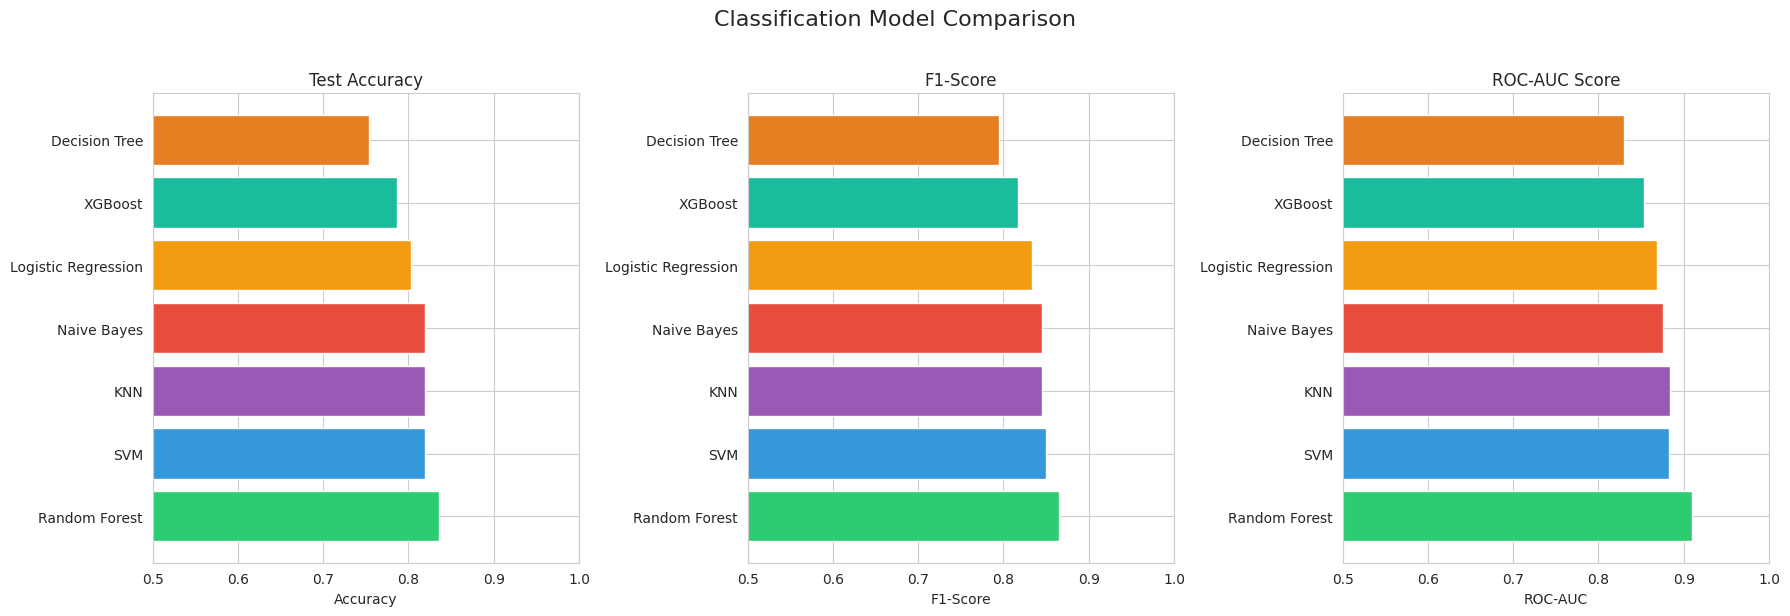

In [14]:
# visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = results_df.index.tolist()
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#f39c12', '#1abc9c', '#e67e22']

# Test Accuracy
axes[0].barh(models, results_df['Test Accuracy'], color=colors[:len(models)])
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Test Accuracy')
axes[0].set_xlim(0.5, 1.0)

# F1-Score
axes[1].barh(models, results_df['F1-Score'], color=colors[:len(models)])
axes[1].set_xlabel('F1-Score')
axes[1].set_title('F1-Score')
axes[1].set_xlim(0.5, 1.0)

# ROC-AUC
roc_vals = results_df['ROC-AUC'].fillna(0)
axes[2].barh(models, roc_vals, color=colors[:len(models)])
axes[2].set_xlabel('ROC-AUC')
axes[2].set_title('ROC-AUC Score')
axes[2].set_xlim(0.5, 1.0)

plt.suptitle('Classification Model Comparison', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../images/05_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Confusion Matrices

A confusion matrix shows:
- **True Positives (TP)**: Correctly predicted heart disease
- **True Negatives (TN)**: Correctly predicted no disease
- **False Positives (FP)**: Predicted disease but patient is healthy ("false alarm")
- **False Negatives (FN)**: Predicted healthy but patient has disease ("missed case")

In medical contexts, **False Negatives are more dangerous** — we don't want to
miss someone who actually has heart disease.

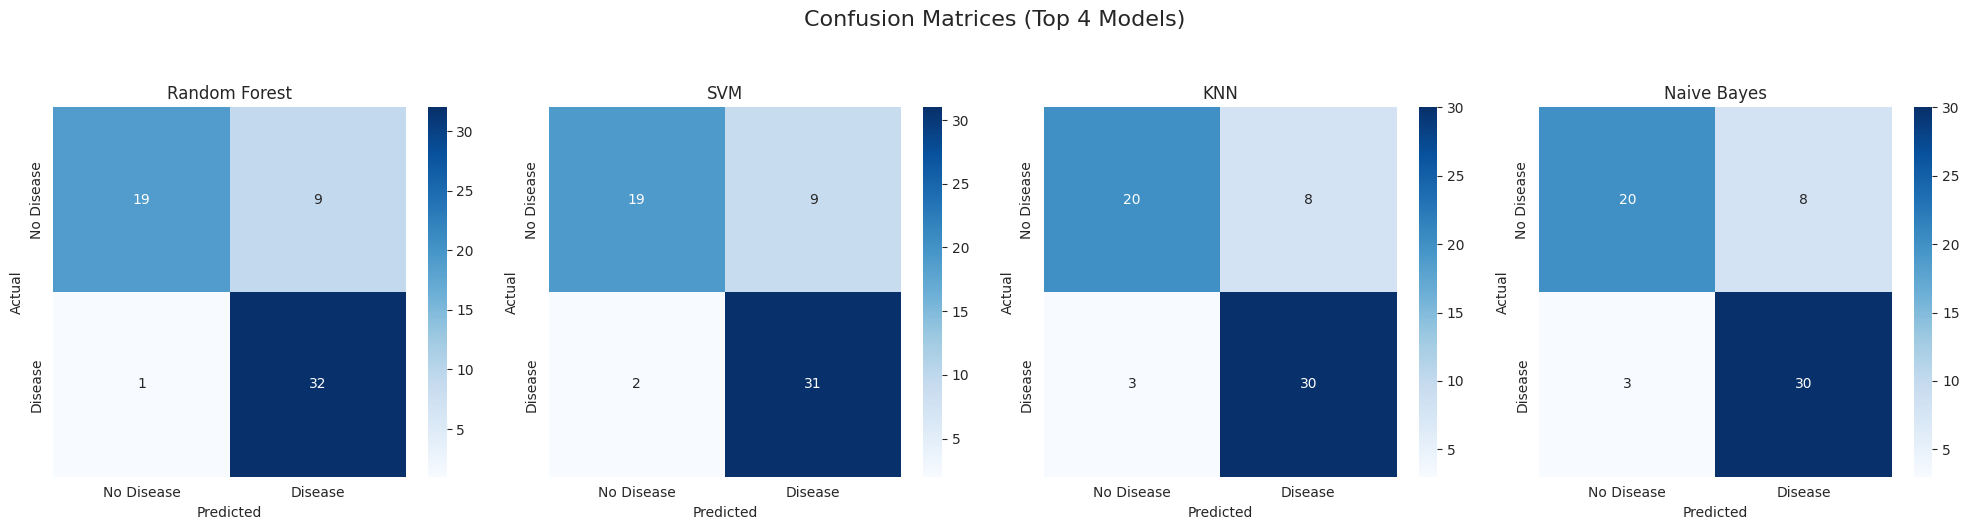

In [15]:
# confusion matrices for top 4 models
top_models = results_df.index[:4].tolist()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, name in enumerate(top_models):
    cm = confusion_matrix(y_test, all_predictions[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])
    axes[i].set_title(name)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices (Top 4 Models)', fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig('../images/05_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. ROC Curves

The ROC curve shows the trade-off between True Positive Rate and False Positive Rate.
A model that hugs the top-left corner is better.

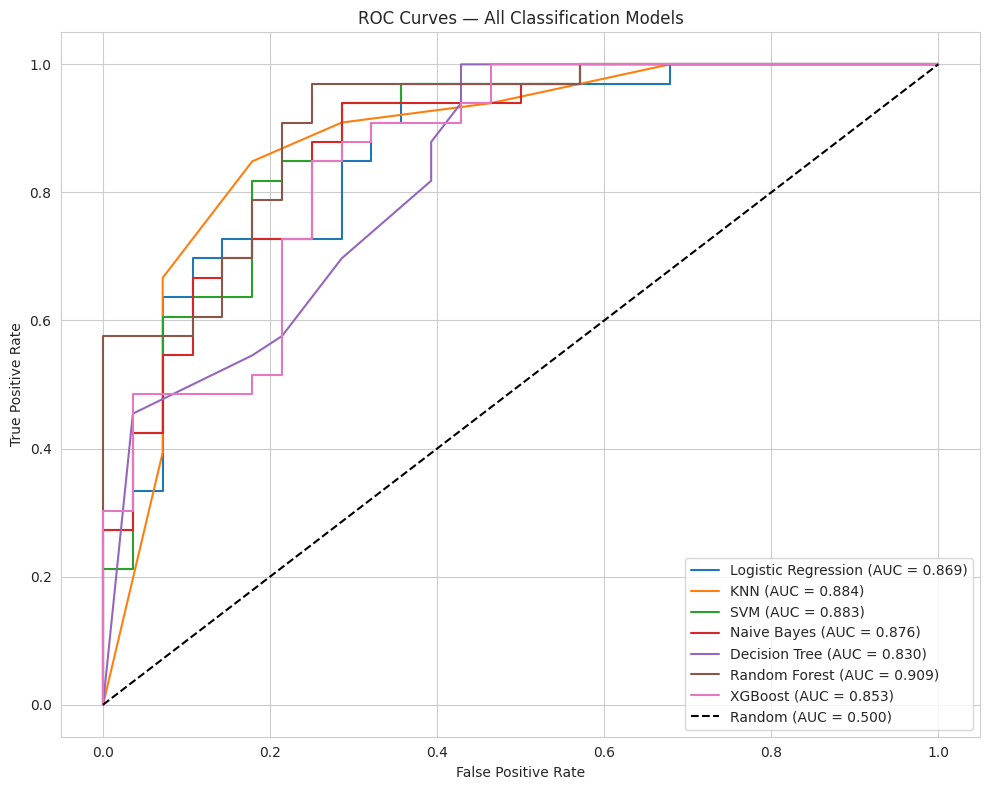

In [16]:
# ROC curves
plt.figure(figsize=(10, 8))

for name, proba in all_probas.items():
    if proba is not None:
        fpr, tpr, _ = roc_curve(y_test, proba)
        auc = roc_auc_score(y_test, proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

# diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.500)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Classification Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../images/05_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Cross-Validation

In [17]:
# cross-validation for all models
cv_models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=42), X_train_scaled),
    'KNN': (KNeighborsClassifier(n_neighbors=7), X_train_scaled),
    'SVM': (SVC(kernel='rbf', random_state=42), X_train_scaled),
    'Random Forest': (RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42), X_train),
    'XGBoost': (XGBClassifier(n_estimators=100, max_depth=5, random_state=42, verbosity=0, eval_metric='logloss'), X_train)
}

print('5-Fold Cross-Validation Results (Accuracy):')
print('-' * 55)

for name, (model, data) in cv_models.items():
    scores = cross_val_score(model, data, y_train, cv=5, scoring='accuracy')
    print(f'{name:25s} | Mean: {scores.mean():.4f} ± {scores.std():.4f}')

print('\nCross-validation helps us trust our results more!')

5-Fold Cross-Validation Results (Accuracy):
-------------------------------------------------------
Logistic Regression       | Mean: 0.8309 ± 0.0409
KNN                       | Mean: 0.8101 ± 0.0343
SVM                       | Mean: 0.8020 ± 0.0388


Random Forest             | Mean: 0.8268 ± 0.0488
XGBoost                   | Mean: 0.7937 ± 0.0454

Cross-validation helps us trust our results more!


## 7. Feature Importance

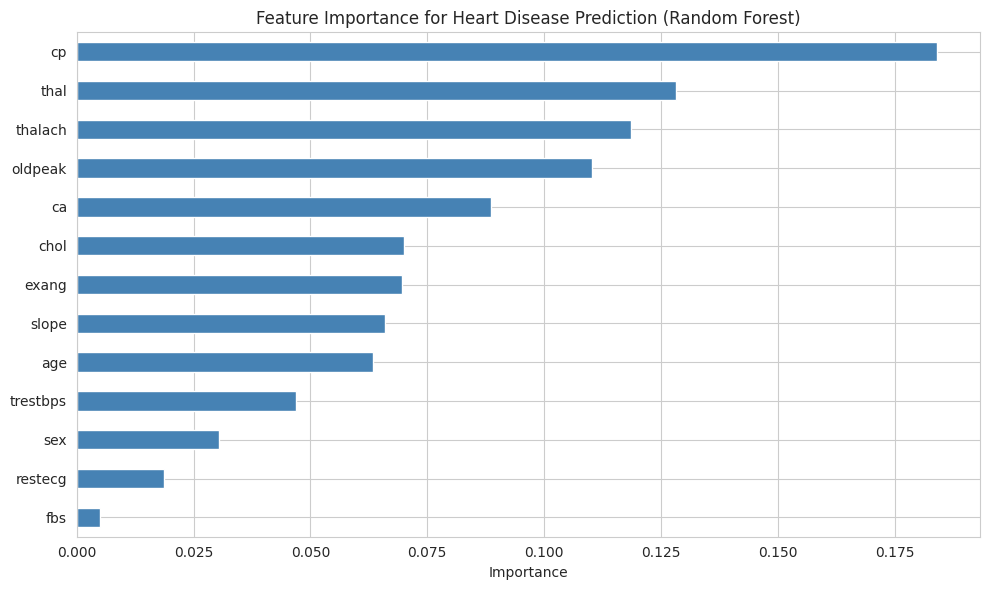

Top 5 most important features:
  ca: 0.0887
  oldpeak: 0.1103
  thalach: 0.1186
  thal: 0.1283
  cp: 0.1841


In [18]:
# feature importance from Random Forest
feature_imp = pd.Series(rf.feature_importances_, index=X_train.columns)
feature_imp = feature_imp.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feature_imp.plot(kind='barh', color='steelblue')
plt.title('Feature Importance for Heart Disease Prediction (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../images/05_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 most important features:')
for feat, imp in feature_imp.tail(5).items():
    print(f'  {feat}: {imp:.4f}')

## 8. Overfitting Check

In [19]:
# overfitting analysis
overfit_df = results_df[['Train Accuracy', 'Test Accuracy']].copy()
overfit_df['Gap'] = overfit_df['Train Accuracy'] - overfit_df['Test Accuracy']
overfit_df['Overfitting?'] = overfit_df['Gap'].apply(
    lambda x: 'Yes ⚠️' if x > 0.05 else 'Minimal ✅'
)

print('Overfitting Analysis:')
overfit_df.round(4)

Overfitting Analysis:


,Train Accuracy,Test Accuracy,Gap,Overfitting?
Model,,,,
Random Forest,0.9587,0.8361,0.1226,Yes ⚠️
SVM,0.9132,0.8197,0.0935,Yes ⚠️
KNN,0.8595,0.8197,0.0398,Minimal ✅
Naive Bayes,0.8430,0.8197,0.0233,Minimal ✅
Logistic Regression,0.8430,0.8033,0.0397,Minimal ✅
XGBoost,1.0000,0.7869,0.2131,Yes ⚠️
Decision Tree,0.8760,0.7541,0.1219,Yes ⚠️


In [20]:
# save results
results_df.to_csv('../data/classification_results.csv')
print('Classification results saved!')

Classification results saved!


## Key Takeaways

1. **Multiple models performed well** — this dataset is well-suited for classification
2. **Logistic Regression** is a surprisingly strong baseline for this problem
3. **Ensemble methods** (Random Forest, XGBoost) are reliable performers
4. **Feature importance** shows that chest pain type, max heart rate, and number of vessels are key predictors
5. In a medical context, we should prioritize **Recall** (catching all positive cases) over Precision

### Next Steps
In the final notebook, we'll bring everything together for a comprehensive summary!